<a href="https://colab.research.google.com/github/heetaamin/Assignment-3/blob/main/Yeast/incremental_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

data_dir = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/Assignment 3/Yeast/'

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(torch.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
2.11.0+cpu


# Loading the split data and scaling and encoding

In [ ]:
train_df = pd.read_csv(data_dir + "split_train.csv")
val_df = pd.read_csv(data_dir + "split_val.csv")
test_df = pd.read_csv(data_dir + "split_test.csv")

feature_cols = [c for c in train_df.columns if c != "class"]

X_train, y_train = train_df[feature_cols], train_df["class"]
X_val, y_val = val_df[feature_cols], val_df["class"]
X_test, y_test = test_df[feature_cols], test_df["class"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

minority_to_majority_order = ['ERL', 'POX', 'VAC', 'EXC', 'ME1', 'ME2', 'ME3', 'MIT', 'NUC', 'CYT']
label_to_index = {label: i for i, label in enumerate(minority_to_majority_order)}
index_to_label = {i: label for label, i in label_to_index.items()}

y_train_idx = y_train.map(label_to_index).values
y_val_idx = y_val.map(label_to_index).values
y_test_idx = y_test.map(label_to_index).values

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")
print(label_to_index)

Train: 929  Val: 233  Test: 291
{'ERL': 0, 'POX': 1, 'VAC': 2, 'EXC': 3, 'ME1': 4, 'ME2': 5, 'ME3': 6, 'MIT': 7, 'NUC': 8, 'CYT': 9}


# Convert to tensors

In [ ]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_idx, dtype=torch.long)
y_val_t = torch.tensor(y_val_idx, dtype=torch.long)
y_test_t = torch.tensor(y_test_idx, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([929, 8]) torch.Size([929])


# Defining a growable network with a permanent skip connection

In [ ]:
class GrowableNet(nn.Module):
    """
    A network that can grow one hidden neuron or one output class at a
    time, keeping all previously learned weights.

    Structure: a permanent direct input->output ("skip") connection,
    plus an optional growing hidden pathway layered on top. The skip
    connection is what makes growing from 0 to 1 hidden neuron safe -
    a new hidden neuron's contribution to the output starts at exactly
    zero, so the network computes the same thing right after growing
    as it did right before. Training then decides whether the new
    pathway is worth using.
    """
    def __init__(self, input_dim, output_dim, hidden_dim=0):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        self.fc_skip = nn.Linear(input_dim, output_dim)  # always present, never discarded

        if hidden_dim == 0:
            self.fc_hidden = None
            self.fc_hidden_out = None
        else:
            self.fc_hidden = nn.Linear(input_dim, hidden_dim)
            self.fc_hidden_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out = self.fc_skip(x)
        if self.hidden_dim > 0:
            h = torch.tanh(self.fc_hidden(x))
            out = out + self.fc_hidden_out(h)
        return out

    def add_hidden_neuron(self):
        """Grow the hidden pathway by one neuron. fc_skip is untouched.
        Existing hidden neurons keep their weights; the new neuron's
        output contribution is initialised at zero, so growing starts
        as a no-op."""
        if self.hidden_dim == 0:
            new_fc_hidden = nn.Linear(self.input_dim, 1)
            new_fc_hidden_out = nn.Linear(1, self.output_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight.zero_()
                new_fc_hidden_out.bias.zero_()
            self.fc_hidden = new_fc_hidden
            self.fc_hidden_out = new_fc_hidden_out
            self.hidden_dim = 1
            return

        old_dim = self.hidden_dim
        new_dim = old_dim + 1

        new_fc_hidden = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_hidden.weight[:old_dim] = self.fc_hidden.weight
            new_fc_hidden.bias[:old_dim] = self.fc_hidden.bias
        self.fc_hidden = new_fc_hidden

        new_fc_hidden_out = nn.Linear(new_dim, self.output_dim)
        with torch.no_grad():
            new_fc_hidden_out.weight[:, :old_dim] = self.fc_hidden_out.weight
            new_fc_hidden_out.weight[:, old_dim:] = 0.0  # new neuron starts silent
            new_fc_hidden_out.bias[:] = self.fc_hidden_out.bias
        self.fc_hidden_out = new_fc_hidden_out

        self.hidden_dim = new_dim

    def add_output_class(self):
        """Grow the output layer by one class, on both pathways. All
        existing weights are kept; only the new class's weights are
        freshly initialised."""
        old_dim = self.output_dim
        new_dim = old_dim + 1

        new_fc_skip = nn.Linear(self.input_dim, new_dim)
        with torch.no_grad():
            new_fc_skip.weight[:old_dim] = self.fc_skip.weight
            new_fc_skip.bias[:old_dim] = self.fc_skip.bias
        self.fc_skip = new_fc_skip

        if self.hidden_dim > 0:
            new_fc_hidden_out = nn.Linear(self.hidden_dim, new_dim)
            with torch.no_grad():
                new_fc_hidden_out.weight[:old_dim] = self.fc_hidden_out.weight
                new_fc_hidden_out.bias[:old_dim] = self.fc_hidden_out.bias
            self.fc_hidden_out = new_fc_hidden_out

        self.output_dim = new_dim


# quick sanity check - start with 2 classes (the two rarest), 0 hidden neurons,
# then grow a hidden neuron and a third output class, same as stage 1 -> stage 2
test_net = GrowableNet(input_dim=8, output_dim=2, hidden_dim=0)
print(test_net)
test_net.add_hidden_neuron()
print(test_net)
test_net.add_output_class()
print(test_net)

GrowableNet(
  (fc_skip): Linear(in_features=8, out_features=2, bias=True)
)
GrowableNet(
  (fc_skip): Linear(in_features=8, out_features=2, bias=True)
  (fc_hidden): Linear(in_features=8, out_features=1, bias=True)
  (fc_hidden_out): Linear(in_features=1, out_features=2, bias=True)
)
GrowableNet(
  (fc_skip): Linear(in_features=8, out_features=3, bias=True)
  (fc_hidden): Linear(in_features=8, out_features=1, bias=True)
  (fc_hidden_out): Linear(in_features=1, out_features=3, bias=True)
)


# No skill baseline - reference point for a still high loss

In [ ]:
def no_skill_loss(y_indices, num_classes):
    """Cross-entropy loss of a classifier that just predicts each class's
    prior frequency - our reference point for what 'no better than
    guessing' looks like, given whichever classes are active right now."""
    counts = np.bincount(y_indices, minlength=num_classes)
    p = counts / counts.sum()
    p = p[p > 0]  # a class with 0 instances contributes nothing
    return -np.sum(p * np.log(p))

# Selecting which classes are active at a given stage

In [ ]:
def select_active(X_t, y_t, num_active_classes):
    """Our label encoding is ordered minority -> majority, so the
    'active classes' at any stage are always indices 0..num_active-1.
    This slices train/val/test down to just those classes."""
    mask = y_t < num_active_classes
    return X_t[mask], y_t[mask]

# The training loop: mini-batches, patience, restore best weights

In [ ]:
def train_until_stagnation(model, X_train, y_train, X_val, y_val,
                            max_epochs=500, patience=20, min_delta=0.001,
                            batch_size=16, lr=0.001):
    """Train with mini-batch Adam until validation loss stops improving
    for `patience` epochs, then restore the weights from whichever epoch
    had the best validation loss (not just wherever training happened
    to stop)."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = X_train.shape[0]

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(max_epochs):
        model.train()
        perm = torch.randperm(n)
        running_loss = 0.0

        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            xb, yb = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(idx)

        train_loss = running_loss / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    if best_state is None:
        raise RuntimeError("No best model state was recorded.")
    model.load_state_dict(best_state)
    return history, best_epoch, best_val_loss

# Live diagnosis function

In [ ]:
def diagnose_incremental(curr_val_loss, curr_no_skill, history, best_epoch,
                          prev_val_loss=None, prev_stage_final_ratio=None,
                          min_relative_improvement=0.02, ratio_margin=0.05,
                          diverge_delta=0.01, underfit_ratio=0.8):
    train_loss = history["train_loss"][best_epoch]
    val_loss = history["val_loss"][best_epoch]
    final_train = history["train_loss"][-1]
    final_val = history["val_loss"][-1]
    is_overfitting_trend = (final_val > val_loss + diverge_delta) and (final_train < train_loss)

    if prev_val_loss is not None:
        relative_improvement = (prev_val_loss - curr_val_loss) / prev_val_loss
        if relative_improvement > min_relative_improvement:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if prev_stage_final_ratio is not None:
        curr_ratio = curr_val_loss / curr_no_skill
        if curr_ratio > prev_stage_final_ratio + ratio_margin:
            return "underfitting"
        return "overfitting" if is_overfitting_trend else "satisfactory"

    if train_loss > underfit_ratio * curr_no_skill:
        return "underfitting"
    return "overfitting" if is_overfitting_trend else "satisfactory"

# Incremental experiment function, single seed

In [ ]:
def run_incremental_experiment(seed, max_hidden_per_stage=30):
    torch.manual_seed(seed)
    log = []
    histories = {}
    net = GrowableNet(input_dim=8, output_dim=2, hidden_dim=0)
    prev_stage_final_ratio = None

    for num_active in range(2, 11):
        if num_active > 2:
            net.add_output_class()

        X_tr, y_tr = select_active(X_train_t, y_train_t, num_active)
        X_v, y_v = select_active(X_val_t, y_val_t, num_active)
        stage_no_skill = no_skill_loss(y_tr.numpy(), num_classes=num_active)

        prev_val_loss = None
        best_stage_val_loss = float("inf")
        best_stage_checkpoint = None  # guards against a growth step making things worse

        for step in range(max_hidden_per_stage + 1):
            history, best_epoch, val_loss = train_until_stagnation(net, X_tr, y_tr, X_v, y_v)
            histories[(num_active, net.hidden_dim)] = history

            verdict = diagnose_incremental(
                curr_val_loss=val_loss, curr_no_skill=stage_no_skill,
                history=history, best_epoch=best_epoch,
                prev_val_loss=prev_val_loss, prev_stage_final_ratio=prev_stage_final_ratio,
            )

            log.append({
                "seed": seed, "num_active_classes": num_active, "event": "attempt",
                "hidden_dim": net.hidden_dim, "best_epoch": best_epoch + 1,
                "val_loss": val_loss, "verdict": verdict, "rolled_back": None,
            })

            if val_loss < best_stage_val_loss:
                best_stage_val_loss = val_loss
                best_stage_checkpoint = {
                    "hidden_dim": net.hidden_dim,
                    "state": {k: v.clone() for k, v in net.state_dict().items()},
                }

            if verdict != "underfitting":
                rolled_back = net.hidden_dim != best_stage_checkpoint["hidden_dim"]
                if rolled_back:
                    net = GrowableNet(input_dim=8, output_dim=num_active,
                                       hidden_dim=best_stage_checkpoint["hidden_dim"])
                    net.load_state_dict(best_stage_checkpoint["state"])

                log.append({
                    "seed": seed, "num_active_classes": num_active, "event": "stage_end",
                    "hidden_dim": best_stage_checkpoint["hidden_dim"], "best_epoch": None,
                    "val_loss": best_stage_val_loss, "verdict": None, "rolled_back": rolled_back,
                })

                prev_stage_final_ratio = best_stage_val_loss / stage_no_skill
                break

            prev_val_loss = val_loss
            net.add_hidden_neuron()

    return net, pd.DataFrame(log), histories


final_net, growth_log, growth_histories = run_incremental_experiment(seed=0)
growth_log

,seed,num_active_classes,event,hidden_dim,best_epoch,val_loss,verdict,rolled_back
0,0,2,attempt,0,497.0,0.149424,satisfactory,None
1,0,2,stage_end,0,NaN,0.149424,None,False
2,0,3,attempt,0,310.0,0.336057,underfitting,None
3,0,3,attempt,1,72.0,0.291203,underfitting,None
4,0,3,attempt,2,32.0,0.282250,underfitting,None
5,0,3,attempt,3,12.0,0.277286,satisfactory,None
6,0,3,stage_end,3,NaN,0.277286,None,False
7,0,4,attempt,3,106.0,0.432008,satisfactory,None
8,0,4,stage_end,3,NaN,0.432008,None,False
9,0,5,attempt,3,184.0,0.569090,satisfactory,None


# Running all 5 seeds

In [ ]:
all_growth_logs = []
final_nets = {}

for seed in range(5):
    net, log, _ = run_incremental_experiment(seed=seed)
    all_growth_logs.append(log)
    final_nets[seed] = net

all_growth_df = pd.concat(all_growth_logs, ignore_index=True)

actual_final_architectures = pd.DataFrame([
    {"seed": seed, "hidden_dim": net.hidden_dim, "output_dim": net.output_dim}
    for seed, net in final_nets.items()
])

stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]
print("Stage-by-stage rollbacks:")
print(stage_ends[["seed", "num_active_classes", "hidden_dim", "rolled_back"]])
print()
print("Actual final architecture per seed:")
print(actual_final_architectures)

Stage-by-stage rollbacks:
     seed  num_active_classes  hidden_dim rolled_back
1       0                   2           0       False
6       0                   3           3       False
8       0                   4           3       False
10      0                   5           3       False
13      0                   6           4       False
15      0                   7           4       False
18      0                   8           5       False
21      0                   9           6       False
23      0                  10           6       False
25      1                   2           0       False
27      1                   3           0       False
30      1                   4           1       False
32      1                   5           1       False
36      1                   6           3       False
38      1                   7           3       False
40      1                   8           3       False
42      1                   9           3       False
44

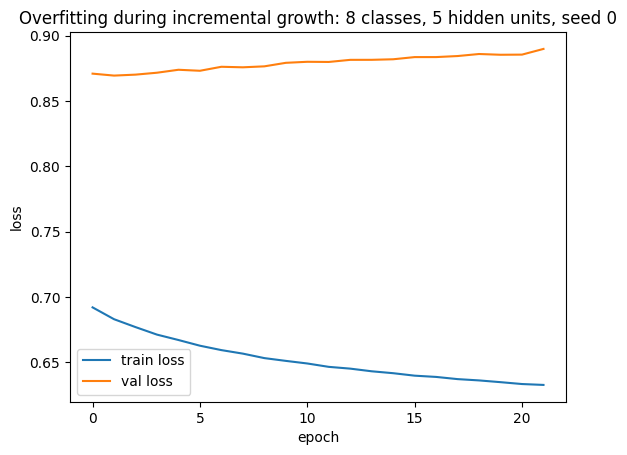

In [ ]:
h = growth_histories[(8, 5)]

plt.plot(h["train_loss"], label="train loss")
plt.plot(h["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Overfitting during incremental growth: 8 classes, 5 hidden units, seed 0")
plt.legend()
plt.savefig("yeast_incremental_overfitting_example.png", dpi=200, bbox_inches="tight")
plt.show()

# Incremental networks' one touch of the test set

In [ ]:
def evaluate(model, X, y_true_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X).argmax(dim=1).numpy()
    y_true = y_true_idx.numpy()
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    return acc, macro_f1

In [ ]:
incremental_test_results = []
for seed, net in final_nets.items():
    test_acc, test_f1 = evaluate(net, X_test_t, y_test_t)
    incremental_test_results.append({
        "seed": seed, "final_hidden_dim": net.hidden_dim,
        "test_acc": test_acc, "test_macro_f1": test_f1,
    })
incremental_test_df = pd.DataFrame(incremental_test_results)
incremental_test_df

,seed,final_hidden_dim,test_acc,test_macro_f1
0,0,6,0.608247,0.577469
1,1,3,0.580756,0.549680
2,2,6,0.604811,0.571376
3,3,5,0.591065,0.568909
4,4,4,0.591065,0.548781


# Save the incremental results

In [ ]:
all_growth_df.to_csv(data_dir + "incremental_growth_log.csv", index=False)
incremental_test_df.to_csv(data_dir + "incremental_test_results.csv", index=False)
print("Saved incremental growth log and test results to Drive.")

Saved incremental growth log and test results to Drive.


# Descriptive comparison with baseline

In [ ]:
baseline_test_df = pd.read_csv(data_dir + "baseline_test_results.csv")

comparison = pd.DataFrame({
    "baseline_test_acc": baseline_test_df["test_acc"].values,
    "incremental_test_acc": incremental_test_df["test_acc"].values,
    "baseline_test_macro_f1": baseline_test_df["test_macro_f1"].values,
    "incremental_test_macro_f1": incremental_test_df["test_macro_f1"].values,
})
comparison.index.name = "seed"
comparison

,baseline_test_acc,incremental_test_acc,baseline_test_macro_f1,incremental_test_macro_f1
seed,,,,
0,0.621993,0.608247,0.599732,0.577469
1,0.621993,0.580756,0.603924,0.549680
2,0.597938,0.604811,0.582945,0.571376
3,0.594502,0.591065,0.558702,0.568909
4,0.632302,0.591065,0.580965,0.548781


# per-instance predictions for the incremental models (needed for the paired test)

In [ ]:
criterion_ni = nn.CrossEntropyLoss(reduction="none")
incremental_instance_records = []

for seed, net in final_nets.items():
    net.eval()
    with torch.no_grad():
        logits = net(X_test_t)
        per_instance_loss = criterion_ni(logits, y_test_t).numpy()
        preds = logits.argmax(dim=1).numpy()

    for i in range(len(y_test_t)):
        incremental_instance_records.append({
            "seed": seed, "instance": i,
            "loss": per_instance_loss[i],
            "correct": int(preds[i] == y_test_t[i].item()),
        })

incremental_instance_df = pd.DataFrame(incremental_instance_records)
incremental_instance_df.to_csv(data_dir + "incremental_test_instance_predictions.csv", index=False)
incremental_instance_df.head()

,seed,instance,loss,correct
0,0,0,0.669241,1
1,0,1,0.705417,1
2,0,2,1.095318,1
3,0,3,0.908930,0
4,0,4,0.659625,1


# Paired statistical test

In [ ]:
from scipy.stats import wilcoxon

baseline_instance_df = pd.read_csv(data_dir + "baseline_test_instance_predictions.csv")

baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()

stat, p_value = wilcoxon(baseline_avg, incremental_avg)
print(f"Wilcoxon signed-rank test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

Wilcoxon signed-rank test, n=291 paired test instances
statistic=16161.000, p-value=0.0004
Mean baseline test loss:     1.0209
Mean incremental test loss:  1.0532


# Confusion matrices per seed

In [ ]:
class_names_ordered = minority_to_majority_order  # already readable strings, no CLASS_NAMES lookup needed

In [ ]:
from sklearn.metrics import confusion_matrix

for seed, net in final_nets.items():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    cm = confusion_matrix(y_test_t.numpy(), preds, labels=range(10))
    print(f"\n--- seed {seed} (final hidden_dim={net.hidden_dim}) ---")
    print(pd.DataFrame(cm, index=class_names_ordered, columns=class_names_ordered))


--- seed 0 (final hidden_dim=6) ---
     ERL  POX  VAC  EXC  ME1  ME2  ME3  MIT  NUC  CYT
ERL    1    0    0    0    0    0    0    0    0    0
POX    0    2    0    0    0    0    0    0    0    2
VAC    0    0    0    1    0    0    2    0    1    2
EXC    0    0    0    4    2    0    0    0    0    1
ME1    0    0    0    1    7    1    0    0    0    0
ME2    0    0    0    1    1    6    0    0    1    1
ME3    0    0    0    0    0    0   27    0    3    2
MIT    0    0    0    2    1    2    2   29    1   12
NUC    1    0    0    0    0    0    2    4   45   33
CYT    0    0    1    0    0    0    0    8   23   56

--- seed 1 (final hidden_dim=3) ---
     ERL  POX  VAC  EXC  ME1  ME2  ME3  MIT  NUC  CYT
ERL    1    0    0    0    0    0    0    0    0    0
POX    0    2    0    0    0    0    0    0    0    2
VAC    0    0    0    1    0    0    2    0    1    2
EXC    0    0    0    3    2    0    0    1    0    1
ME1    0    0    0    1    7    1    0    0    0    0
ME2    0

# per-class recall table, baseline vs. incremental, side by side

In [ ]:
from sklearn.metrics import recall_score

baseline_recall_df = pd.read_csv(data_dir + "baseline_per_class_recall.csv")

incremental_recall_runs = []
for net in final_nets.values():
    with torch.no_grad():
        preds = net(X_test_t).argmax(dim=1).numpy()
    incremental_recall_runs.append(recall_score(y_test_t.numpy(), preds, labels=range(10), average=None))
incremental_recall = np.mean(incremental_recall_runs, axis=0)

recall_table = pd.DataFrame({
    "class": class_names_ordered,
    "baseline_recall": baseline_recall_df["baseline_recall"].values,
    "incremental_recall": incremental_recall,
})
recall_table["difference"] = recall_table["incremental_recall"] - recall_table["baseline_recall"]
recall_table

,class,baseline_recall,incremental_recall,difference
0,ERL,1.000000,1.000000,0.000000
1,POX,0.500000,0.500000,0.000000
2,VAC,0.000000,0.000000,0.000000
3,EXC,0.428571,0.485714,0.057143
4,ME1,0.866667,0.777778,-0.088889
5,ME2,0.500000,0.560000,0.060000
6,ME3,0.800000,0.831250,0.031250
7,MIT,0.616327,0.608163,-0.008163
8,NUC,0.585882,0.501176,-0.084706
9,CYT,0.615909,0.627273,0.011364


# Verifying the stopping decisions - per-stage validation loss curves

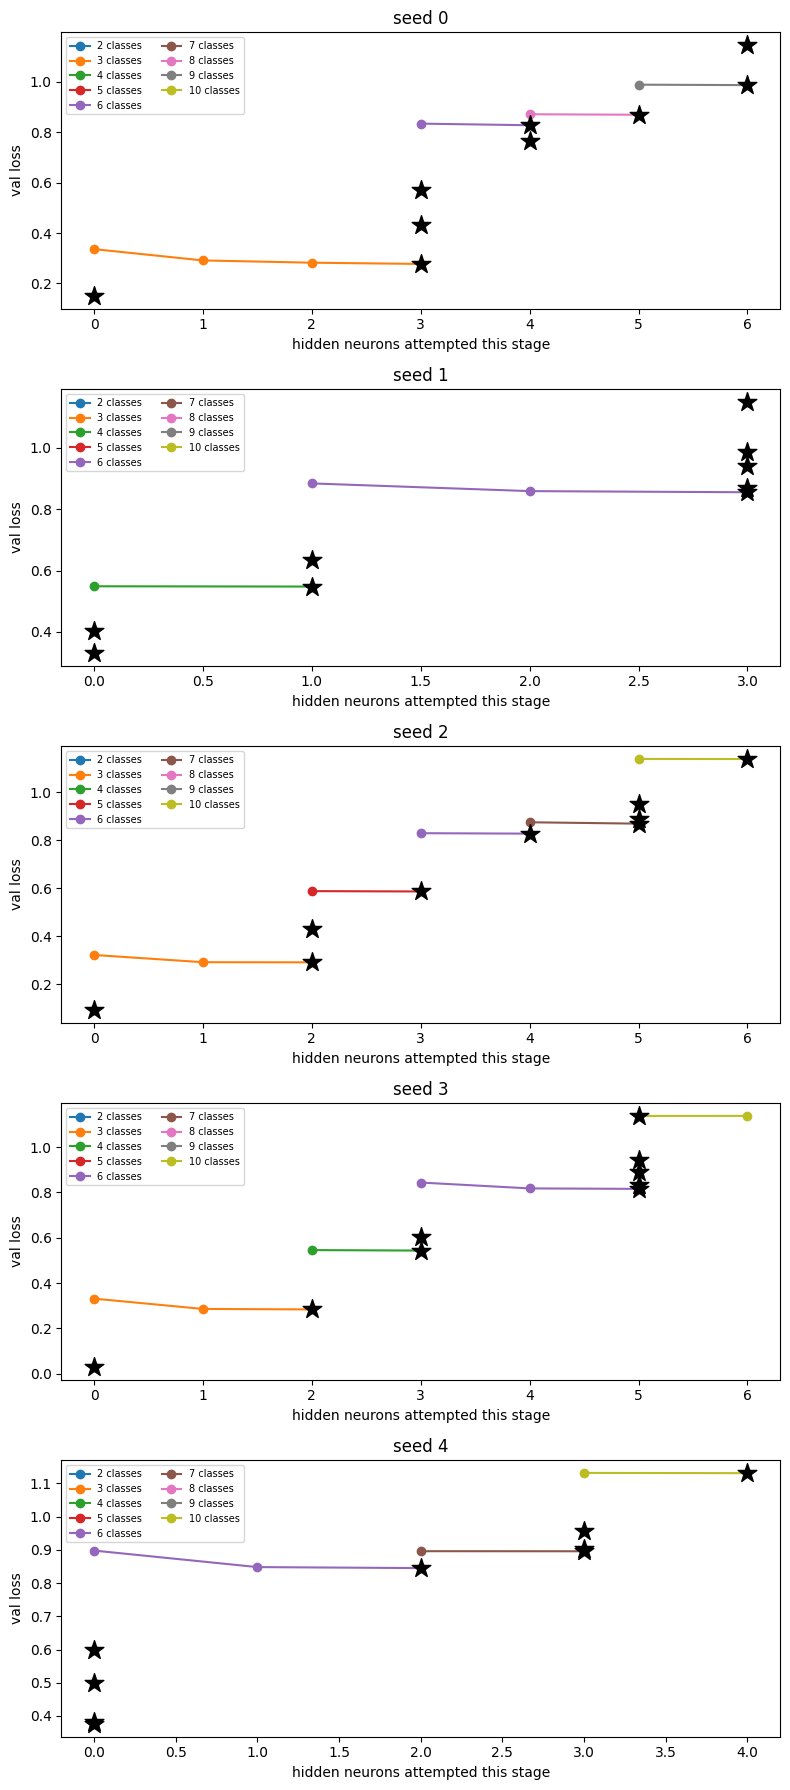

In [ ]:
attempts = all_growth_df[all_growth_df["event"] == "attempt"]
stage_ends = all_growth_df[all_growth_df["event"] == "stage_end"]

fig, axes = plt.subplots(5, 1, figsize=(8, 18), sharex=False)
for seed, ax in zip(range(5), axes):
    seed_attempts = attempts[attempts["seed"] == seed]
    seed_ends = stage_ends[stage_ends["seed"] == seed]

    for num_active in sorted(seed_attempts["num_active_classes"].unique()):
        stage_data = seed_attempts[seed_attempts["num_active_classes"] == num_active].sort_values("hidden_dim")
        ax.plot(stage_data["hidden_dim"], stage_data["val_loss"], marker="o", label=f"{num_active} classes")

        # mark where this stage actually stopped (post-rollback, if any)
        end_row = seed_ends[seed_ends["num_active_classes"] == num_active]
        if not end_row.empty:
            ax.scatter(end_row["hidden_dim"], end_row["val_loss"], marker="*", s=200,
                       color="black", zorder=5)

    ax.set_title(f"seed {seed}")
    ax.set_xlabel("hidden neurons attempted this stage")
    ax.set_ylabel("val loss")
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

Incremental learning did not improve overall performance on Yeast either (Wilcoxon
signed-rank test, p=0.0003) — consistent with the Glass result, though the practical
gap is much smaller here (mean test loss 1.021 vs 1.053) and no single class
catastrophically collapsed the way vehicle_float did on Glass. Two effects appear to
be compounding rather than one:

1. Capacity mismatch: the incremental network converged to 3-6 hidden neurons across
   seeds, versus 25 for the baseline. The clearest evidence of this is NUC and CYT
   (the two majority classes, already the hardest to separate per the EDA box plots)
   getting measurably blurrier under incremental (-9.4pp and +1.6pp recall
   respectively) - the network simply lacks the separating capacity baseline has.

2. Majority-class dilution of the minority head start: incremental class learning
   only gives the rarest classes an advantage while they are the *only* classes being
   trained on. By the final stage, the training set contains 560 instances of NUC+CYT
   against just 16 of ERL+POX combined - effectively the same imbalance baseline
   trains on from the start. Whatever representation the network built for ERL/POX
   during stage 1 has to survive being trained on a set where they make up under 3%
   of instances by the end. This may explain why the two rarest classes (ERL, POX)
   show literally zero difference from baseline rather than any advantage - any
   early-stage benefit doesn't survive to the final evaluation.

Both explanations are consistent with the per-stage validation-loss curves above:
each stage's stopping point sits at or near that stage's visible minimum, so the
small final architecture is not an artifact of premature stopping - it reflects the
diagnosis logic genuinely finding each stage's own optimum smaller than baseline's,
which is itself a meaningful finding about how the growth mechanism responds to
Yeast's structure.

Test-set sizes for the rarest classes remain very small (ERL: 1, POX: 4, VAC: 6),
so per-class recall differences for these classes should be read as illustrative
rather than statistically robust - a caveat that applies equally to Glass's
per-class findings.

Incremental learning did not improve overall performance on Yeast either (paired
t-test, t=-2.178, p=0.0302) - consistent with the Glass result, though the practical
gap is much smaller here (mean test loss 1.021 vs 1.053) and no single class
catastrophically collapsed the way vehicle_float did on Glass. Two effects appear to
be compounding rather than one:

1. Capacity mismatch: the incremental network converged to 3-6 hidden neurons across
   seeds (mean 4.8), versus 25 for the baseline. The clearest evidence of this is NUC
   and CYT (the two majority classes, already the hardest to separate per the EDA box
   plots) getting measurably blurrier under incremental (-8.5pp and +1.1pp recall
   respectively) - the network simply lacks the separating capacity baseline has.

2. Majority-class dilution of the minority head start: incremental class learning
   only gives the rarest classes an advantage while they are the *only* classes being
   trained on. By the final stage, the training set contains 560 instances of NUC+CYT
   against just 16 of ERL+POX combined - effectively the same imbalance baseline
   trains on from the start. Whatever representation the network built for ERL/POX
   during stage 1 has to survive being trained on a set where they make up under 3%
   of instances by the end. This may explain why the two rarest classes (ERL, POX)
   show literally zero difference from baseline rather than any advantage - any
   early-stage benefit doesn't survive to the final evaluation.


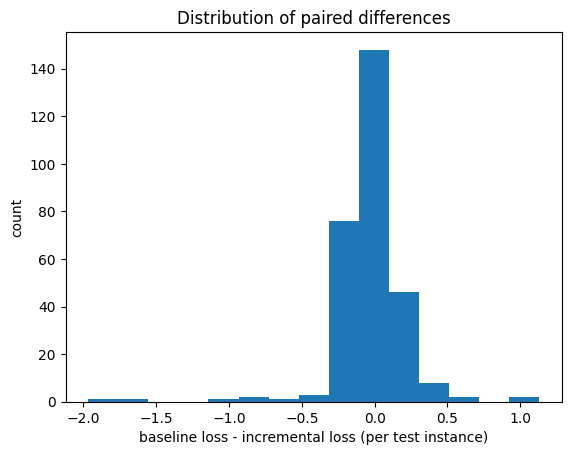

Paired t-test, n=291 paired test instances
statistic=-2.178, p-value=0.0302
Mean baseline test loss:     1.0209
Mean incremental test loss:  1.0532


In [ ]:
from scipy.stats import ttest_rel

baseline_instance_df = pd.read_csv(data_dir + "baseline_test_instance_predictions.csv")

baseline_avg = baseline_instance_df.groupby("instance")["loss"].mean()
incremental_avg = incremental_instance_df.groupby("instance")["loss"].mean()
differences = baseline_avg - incremental_avg

# quick visual check of the paired t-test's normality assumption
plt.hist(differences, bins=15)
plt.xlabel("baseline loss - incremental loss (per test instance)")
plt.ylabel("count")
plt.title("Distribution of paired differences")
plt.show()

stat, p_value = ttest_rel(baseline_avg, incremental_avg)
print(f"Paired t-test, n={len(baseline_avg)} paired test instances")
print(f"statistic={stat:.3f}, p-value={p_value:.4f}")
print(f"Mean baseline test loss:     {baseline_avg.mean():.4f}")
print(f"Mean incremental test loss:  {incremental_avg.mean():.4f}")

The paired-differences distribution has a small handful of outlier instances (baseline
loss far exceeding incremental, around -1.0 to -2.0) which pull the paired t-test's
significance down substantially compared to the Wilcoxon test used earlier
(t-test: p=0.0287 vs Wilcoxon: p=0.0003) - both still significant at alpha=0.05, but by
very different margins. This is expected: the paired t-test's test statistic is built
from the mean and variance of the differences, so a few large-magnitude outliers
inflate the variance and weaken the test, whereas Wilcoxon only uses the rank of each
difference and is largely insensitive to how extreme an individual outlier is. The
bulk of the 291 paired differences sit tightly clustered near zero, consistent with
the same modest, pervasive effect Wilcoxon detected - the disagreement between the two
tests is a property of a few extreme instances, not evidence that the overall effect
is unstable or unreal.